# 03 — Baseline Models

Establishes a performance floor before training any ML model.

**Naive baselines (no ML):**
- Persistence: predict `current_occ` (assume nothing changes)
- Historical mean: predict `hist_mean_occ` (average for this station/hour/day-of-week)

**ML baseline:**
- Linear Regression with a sklearn Pipeline (StandardScaler + LinearRegression)

Any model in notebooks 04-05 must beat the naive baselines to be useful,
and should meaningfully improve on Linear Regression to justify the complexity.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.utils.config import PATHS, FEATURES, TARGET, SPLIT_DATE, RANDOM_STATE, DATASET_FILE
from src.models.evaluate import regression_metrics, naive_metrics, plot_predictions, plot_residuals

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load dataset

In [2]:
df = pd.read_parquet(DATASET_FILE)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f'Rows:      {len(df):,}')
print(f'Stations:  {df["station_id"].nunique()}')
print(f'Horizons:  {sorted(df["horizon_hours"].unique())}')

Rows:      20,142,030
Stations:  510
Horizons:  [np.int8(1), np.int8(3), np.int8(6), np.int8(12), np.int8(24)]


---
## 2. Temporal train/test split

No random splits — this is a time series. The model trains on the past
and is evaluated on data it has never seen.

In [3]:
train = df[df['datetime_hour'] < SPLIT_DATE].copy()
test  = df[df['datetime_hour'] >= SPLIT_DATE].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {len(train):,} rows  ({train["datetime_hour"].min().date()} → {train["datetime_hour"].max().date()})')
print(f'Test:  {len(test):,} rows   ({test["datetime_hour"].min().date()} → {test["datetime_hour"].max().date()})')

Train: 16,476,930 rows  (2024-01-07 → 2024-10-31)
Test:  3,665,100 rows   (2024-11-01 → 2024-12-31)


---
## 3. Naive baselines

In [4]:
naive_results = naive_metrics(
    y_true        = y_test,
    y_persistence = test['current_occ'],
    y_hist_mean   = test['hist_mean_occ'],
)

=== NAIVE BASELINES ===
  Persistence (current_occ)
    RMSE : 0.2351
    MAE  : 0.1601
    R²   : 0.2881
  Historical mean (hist_mean_occ)
    RMSE : 0.2364
    MAE  : 0.1841
    R²   : 0.2803


---
## 4. Linear Regression

Using a Pipeline so the scaler and model are always applied together.
The scaler is fit on training data only.

In [5]:
# Wrapping scaler + model in a Pipeline means they're always applied together.
# This matters at deployment: one joblib file, no risk of forgetting to scale.
# The scaler is fit on training data only (fit_transform on train, transform on test).
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])

pipeline_lr.fit(X_train, y_train)
print('Model trained.')

Model trained.


---
## 5. Evaluate

In [6]:
y_pred_train = pipeline_lr.predict(X_train)
y_pred_test  = pipeline_lr.predict(X_test)

avg_capacity = float(df['capacity'].drop_duplicates().mean())

print('=== LINEAR REGRESSION ===')
m_train = regression_metrics(y_train, y_pred_train, 'Train', avg_capacity)
print()
m_test  = regression_metrics(y_test,  y_pred_test,  'Test',  avg_capacity)

=== LINEAR REGRESSION ===
  Train
    RMSE : 0.2115
    MAE  : 0.1645
    R²   : 0.4114
    RMSE in bikes : ±6.9

  Test
    RMSE : 0.1964
    MAE  : 0.1529
    R²   : 0.5032
    RMSE in bikes : ±6.4


---
## 6. Evaluate by horizon

A good model should improve relative to naive baselines across all horizons,
but errors should grow as the horizon increases.

 horizon_hours     rmse
             1 0.142827
             3 0.170289
             6 0.198835
            12 0.248789
            24 0.205770


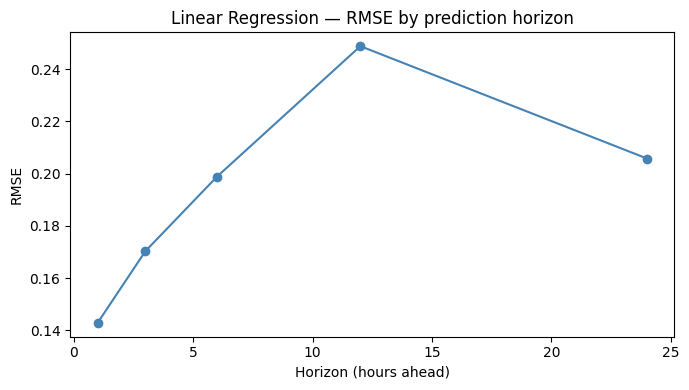

In [7]:
from sklearn.metrics import mean_squared_error

results_by_horizon = []
for h in sorted(test['horizon_hours'].unique()):
    mask = test['horizon_hours'] == h
    rmse = float(np.sqrt(mean_squared_error(y_test[mask], y_pred_test[mask])))
    results_by_horizon.append({'horizon_hours': h, 'rmse': rmse})

df_h = pd.DataFrame(results_by_horizon)
print(df_h.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_h['horizon_hours'], df_h['rmse'], marker='o', color='steelblue')
ax.set_xlabel('Horizon (hours ahead)')
ax.set_ylabel('RMSE')
ax.set_title('Linear Regression — RMSE by prediction horizon')
plt.tight_layout()
plt.savefig(PATHS['figures'] / '03_lr_rmse_by_horizon.png', dpi=150)
plt.show()

---
## 7. Coefficient interpretation

In [8]:
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': pipeline_lr.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

        feature  coefficient
    current_occ     0.124845
     dist_beach    -0.053409
        lag_24h     0.043167
    dist_center     0.039354
       lag_168h     0.032972
target_hour_cos     0.015377
target_hour_sin     0.013880
       hour_cos    -0.011464
rolling_mean_3h    -0.009086
  hist_mean_occ     0.007842
       hour_sin    -0.002807
    temperature    -0.002068
       capacity    -0.002042
      month_cos     0.001781
        dow_cos    -0.001193
     is_holiday     0.000968
      month_sin     0.000945
  precipitation     0.000902
     is_weekend     0.000437
      windspeed    -0.000207
        dow_sin     0.000164
  horizon_hours     0.000019


---
## 8. Plots

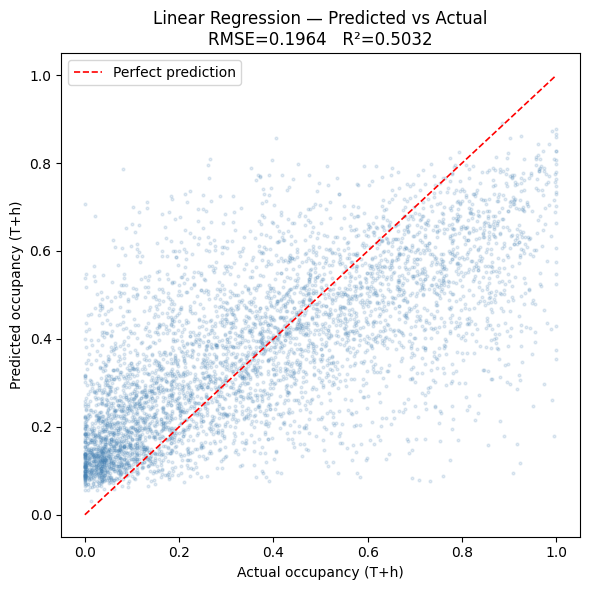

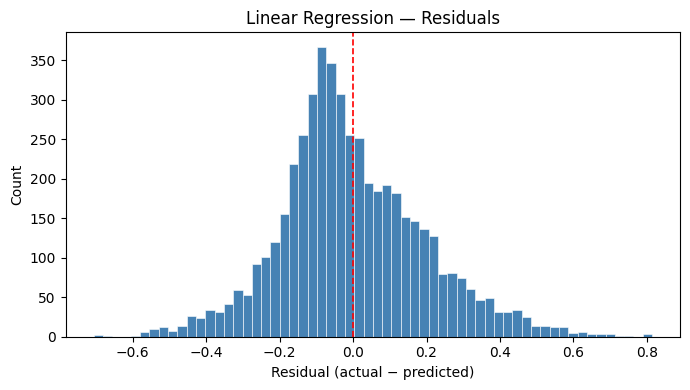

In [9]:
fig = plot_predictions(y_test.values, y_pred_test,
                       rmse=m_test['rmse'], r2=m_test['r2'],
                       title='Linear Regression — Predicted vs Actual')
fig.savefig(PATHS['figures'] / '03_lr_predictions.png', dpi=150)
plt.show()

fig = plot_residuals(y_test.values, y_pred_test, title='Linear Regression — Residuals')
fig.savefig(PATHS['figures'] / '03_lr_residuals.png', dpi=150)
plt.show()

---
## 9. Save model

In [10]:
model_path = PATHS['models'] / 'linear_regression.joblib'
joblib.dump(pipeline_lr, model_path)
print(f'Model saved to {model_path}')

Model saved to C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\models\linear_regression.joblib
